# Child Food Allergy Regression

This notebook contains the regression-focused cells split from `Child_Food_Allergy.ipynb`.


In [17]:
# packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import HTML
HTML('''
<style>
div.input {display:none;}
</style>
''')

In [18]:
# read the original data
children = pd.read_csv('child24.csv')


In [19]:
# DEMOGRAPHICS

demographics = ["SEX_C", "RELTIVP_C", "RACEALLP_C"]

# MAIN OUTCOME
main_outcome = ["PHSTAT_C"]

# PSYCHOSOCIAL COVARIATES
psychosocial_covariates = ["ANXFREQ_C", "DEPFREQ_C", "SCHDYMSSTC_C"]

# SOCIAL DETERMINANTS OF HEALTH COVARIATES

# Income, Insurance

social_determinants = ["NOTCOV_C", "COVER_C", "FSNAP12M_C", "FWIC12M_C", "FLUNCH12M1_C"]

# Education
education = ["MAXPAREDUP_C"]

# Food Security

# FDSCAT34_C
food_security = ["FDSCAT3_C", "FDSCAT4_C"]

# Housing
housing = ["HOUTENURE_C"]

# Built Environment
built_environment = ["SIDEWALK_C", "PARKS_C", "TRAFFIC_C", "CRIME_C"]

# ELIGIBILITY
eligibility = ["AGEP_C", "CURFOOD_C"]

# Variables
variables = [
    *demographics,
    *main_outcome,
    *psychosocial_covariates,
    *social_determinants,
    *education,
    *food_security,
    *housing,
    *built_environment,
    *eligibility
]


child_data = children[variables]

In [20]:
# Limit the age range

children_with_age_range = child_data[
    child_data["AGEP_C"].between(5, 17)
]

# children_with_age_range

## Logistic Regression for Food Allergy

This section fits a multivariable logistic regression model to identify psychosocial and socioeconomic factors associated with current food allergy among children ages 5-17. Variables are dichotomized using the same logic used earlier in this notebook whenever applicable.


Excluded variables from the logistic regression:
RACEALLP_C,  RELTIVP_C,  FDSCAT3_C,  CURFOOD_C (restricted to allergy only)

Modified model sample size: 449
Poor health = 1: 34
Poor health = 0: 415

Modified logistic regression results:


,label,odds_ratio,ci_lower,ci_upper,p_value,significant
0,High Depression,4.432635,1.559581,12.598414,0.005209,True
1,High Absence,4.179416,1.450085,12.045857,0.008096,True
2,School Meal High Risk,2.504809,0.994376,6.309552,0.051415,False
3,No Sidewalk High Risk,2.045918,0.699657,5.982619,0.191020,False
4,Food Insecurity,1.757172,0.709298,4.353110,0.223270,False
5,Low Parent Education (0-5 vs 6-10),1.591156,0.661217,3.828969,0.299894,False
6,Housing: Rented vs Owned,1.569480,0.663227,3.714065,0.305075,False
7,No Parks High Risk,1.187424,0.485496,2.904197,0.706575,False
8,WIC High Risk,1.151848,0.232386,5.709258,0.862577,False
9,High Anxiety,1.110424,0.408564,3.017992,0.837321,False



Model comparison:
- Existing model sample size: 8,234
- Modified model sample size: 449


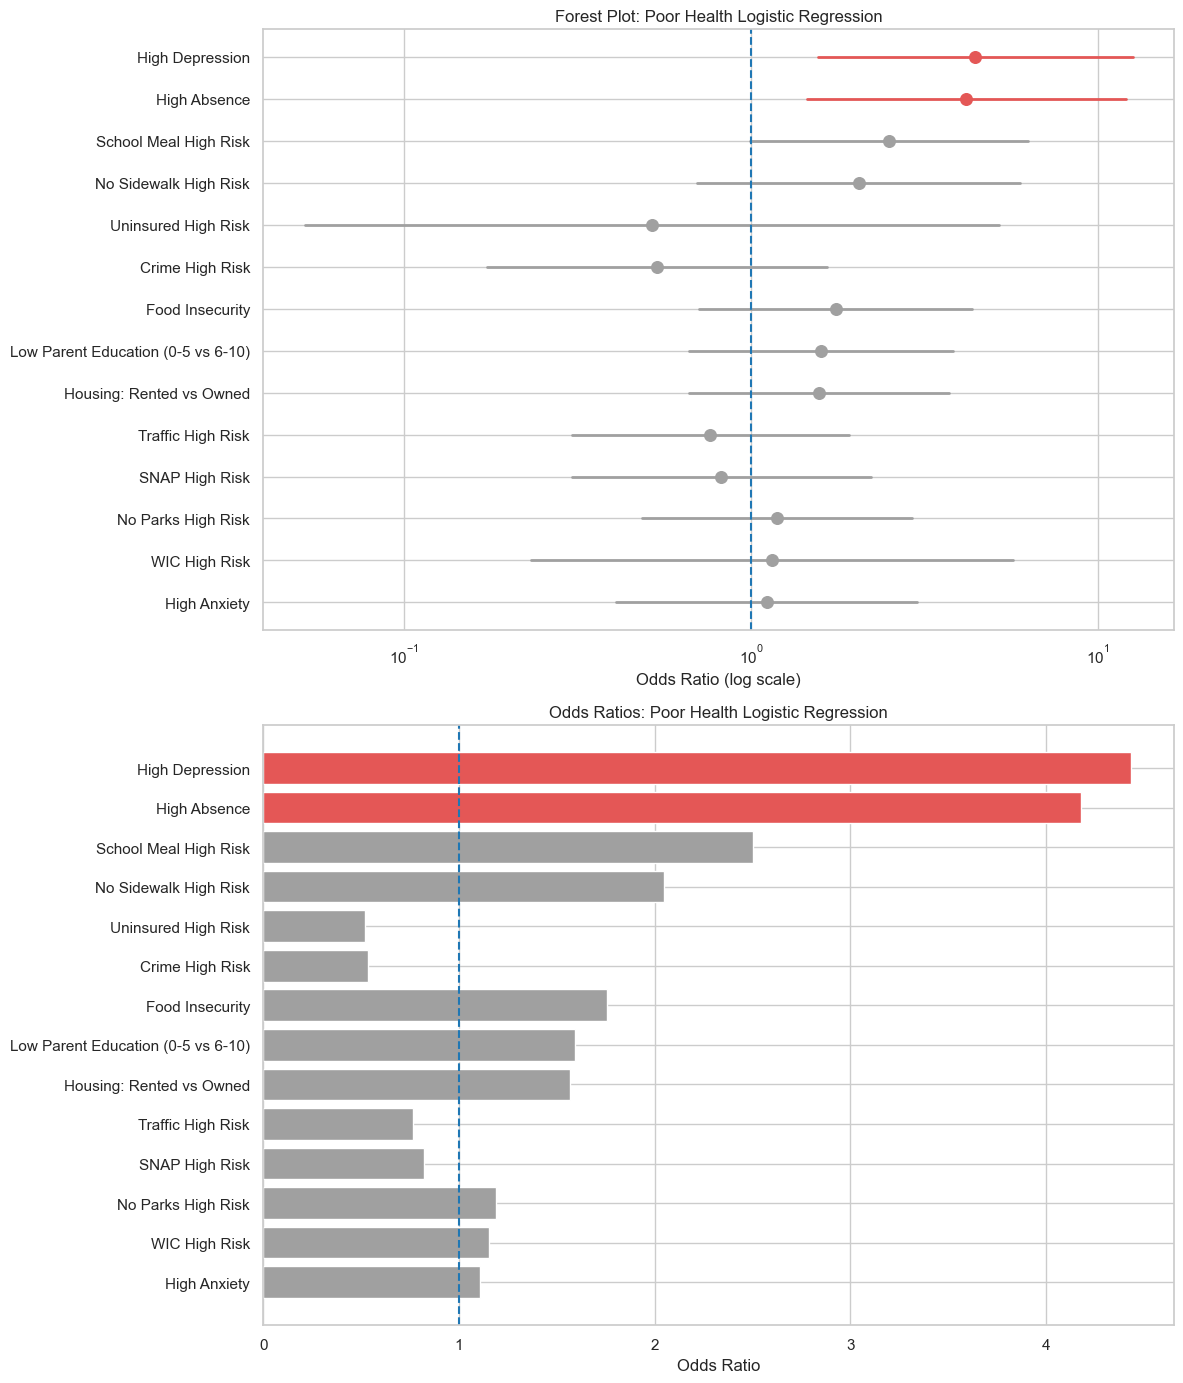

Interpretation:
- High Depression is significantly associated with poor health (OR=4.43, 95% CI 1.56-12.60, p=0.00521). This corresponds to 4.43 times higher odds.
- High Absence is significantly associated with poor health (OR=4.18, 95% CI 1.45-12.05, p=0.0081). This corresponds to 4.18 times higher odds.
- In this modified model, poor health is the outcome.
- The analysis is restricted to children with current food allergy (CURFOOD_C = 1).


In [21]:
import statsmodels.api as sm
from IPython.display import display

# =========================================================
# Modified Logistic Regression
# Outcome = poor_health
# Restricted to children with food allergy
# Age group added
# =========================================================

# -----------------------------------
# 0) Variables excluded from this logistic regression
# -----------------------------------
print("Excluded variables from the logistic regression:")
print("RACEALLP_C, ", "RELTIVP_C, ", "FDSCAT3_C, ", "CURFOOD_C (restricted to allergy only)")

# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

# Age filter: 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# Restrict to children with food allergy only: CURFOOD_C = 1
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df = df[curfood == 1].copy()

# Outcome: poor health
ph = pd.to_numeric(df["PHSTAT_C"], errors="coerce")
df["poor_health"] = np.where(
    ph.isin([4, 5]), 1,
    np.where(ph.isin([1, 2, 3]), 0, np.nan)
)

# Psychosocial
anx = pd.to_numeric(df["ANXFREQ_C"], errors="coerce")
df["high_anxiety"] = np.where(
    anx.isin([1, 2, 3]), 1,
    np.where(anx.isin([4, 5]), 0, np.nan)
)

dep = pd.to_numeric(df["DEPFREQ_C"], errors="coerce")
df["high_depression"] = np.where(
    dep.isin([1, 2,3]), 1,
    np.where(dep.isin([4, 5]), 0, np.nan)
)

sch = pd.to_numeric(df["SCHDYMSSTC_C"], errors="coerce")
df["high_absence"] = np.where(
    sch.between(18, 95), 1,
    np.where(sch.between(0, 17), 0, np.nan)
)

# SDOH / socioeconomic
notcov = pd.to_numeric(df["NOTCOV_C"], errors="coerce")
df["notcov_risk"] = np.where(notcov == 1, 1, np.where(notcov == 2, 0, np.nan))

cover = pd.to_numeric(df["COVER_C"], errors="coerce")

snap = pd.to_numeric(df["FSNAP12M_C"], errors="coerce")
df["snap_risk"] = np.where(snap == 1, 1, np.where(snap == 2, 0, np.nan))

wic = pd.to_numeric(df["FWIC12M_C"], errors="coerce")
df["wic_risk"] = np.where(wic == 1, 1, np.where(wic == 2, 0, np.nan))

meal = pd.to_numeric(df["FLUNCH12M1_C"], errors="coerce")
df["meal_risk"] = np.where(meal == 1, 1, np.where(meal == 2, 0, np.nan))

# Education: binary
maxedu = pd.to_numeric(df["MAXPAREDUP_C"], errors="coerce")
df["low_parent_education"] = np.where(
    maxedu.between(0, 5), 1,
    np.where(maxedu.between(6, 10), 0, np.nan)
)

# Food security
fd = pd.to_numeric(df["FDSCAT4_C"], errors="coerce")
df["food_insecure"] = np.where(
    fd.isin([3,4]), 1,
    np.where(fd.isin([1,2]), 0, np.nan)
)

# Housing: rented vs owned
house = pd.to_numeric(df["HOUTENURE_C"], errors="coerce")
df["housing_rented"] = np.where(house == 2, 1, np.where(house == 1, 0, np.nan))

# Built environment
sidewalk = pd.to_numeric(df["SIDEWALK_C"], errors="coerce")
parks = pd.to_numeric(df["PARKS_C"], errors="coerce")
traffic = pd.to_numeric(df["TRAFFIC_C"], errors="coerce")
crime = pd.to_numeric(df["CRIME_C"], errors="coerce")

df["sidewalk_high_risk"] = np.where(sidewalk == 2, 1, np.where(sidewalk == 1, 0, np.nan))
df["parks_high_risk"] = np.where(parks == 2, 1, np.where(parks == 1, 0, np.nan))
df["traffic_high_risk"] = np.where(traffic == 1, 1, np.where(traffic == 2, 0, np.nan))
df["crime_high_risk"] = np.where(crime == 1, 1, np.where(crime == 2, 0, np.nan))

# Complete cases
analysis_df_mod = df[[
    "poor_health",
    "high_anxiety",
    "high_depression",
    "high_absence",
    "notcov_risk",
    "snap_risk",
    "wic_risk",
    "meal_risk",
    "low_parent_education",
    "food_insecure",
    "housing_rented",
    "sidewalk_high_risk",
    "parks_high_risk",
    "traffic_high_risk",
    "crime_high_risk"
]].dropna().copy()

for col in analysis_df_mod.columns:
    analysis_df_mod[col] = analysis_df_mod[col].astype(int)

zero_variance_cols = [
    col for col in analysis_df_mod.columns
    if col != "poor_health" and analysis_df_mod[col].nunique() < 2
]
if zero_variance_cols:
    print("\nDropped zero-variance predictors:", ", ".join(zero_variance_cols))
    analysis_df_mod = analysis_df_mod.drop(columns=zero_variance_cols)

print(f"\nModified model sample size: {len(analysis_df_mod):,}")
print(f"Poor health = 1: {analysis_df_mod['poor_health'].sum():,}")
print(f"Poor health = 0: {(analysis_df_mod['poor_health'] == 0).sum():,}")

# -----------------------------------
# 2) Logistic regression
# -----------------------------------
X = analysis_df_mod.drop(columns=["poor_health"]).copy()
X = sm.add_constant(X, has_constant="add")
y = analysis_df_mod["poor_health"]

logit_model = sm.Logit(y, X)
logit_result = logit_model.fit(disp=False, maxiter=300)

coef_df_mod = pd.DataFrame({
    "variable": logit_result.params.index,
    "beta": logit_result.params.values,
    "odds_ratio": np.exp(logit_result.params.values),
    "p_value": logit_result.pvalues.values
})

conf = logit_result.conf_int()
coef_df_mod["ci_lower"] = np.exp(conf[0].values)
coef_df_mod["ci_upper"] = np.exp(conf[1].values)
coef_df_mod = coef_df_mod[coef_df_mod["variable"] != "const"].copy()
coef_df_mod["significant"] = coef_df_mod["p_value"] < 0.05
coef_df_mod["effect_size"] = np.abs(np.log(coef_df_mod["odds_ratio"]))

name_map = {
    "high_anxiety": "High Anxiety",
    "high_depression": "High Depression",
    "high_absence": "High Absence",
    "notcov_risk": "Uninsured High Risk",
    "snap_risk": "SNAP High Risk",
    "wic_risk": "WIC High Risk",
    "meal_risk": "School Meal High Risk",
    "low_parent_education": "Low Parent Education (0-5 vs 6-10)",
    "food_insecure": "Food Insecurity",
    "housing_rented": "Housing: Rented vs Owned",
    "sidewalk_high_risk": "No Sidewalk High Risk",
    "parks_high_risk": "No Parks High Risk",
    "traffic_high_risk": "Traffic High Risk",
    "crime_high_risk": "Crime High Risk"
}
coef_df_mod["label"] = coef_df_mod["variable"].map(name_map).fillna(coef_df_mod["variable"])

results_or = coef_df_mod.sort_values("odds_ratio", ascending=False).reset_index(drop=True)
results_effect = coef_df_mod.sort_values(["effect_size", "p_value"], ascending=[False, True]).reset_index(drop=True)
sig_results = results_or[results_or["significant"]].copy()

print("\nModified logistic regression results:")
display(results_or[["label", "odds_ratio", "ci_lower", "ci_upper", "p_value", "significant"]])


# -----------------------------------
# 3) Sample size comparison
# -----------------------------------
print("\nModel comparison:")
if "analysis_df" in globals():
    print(f"- Existing model sample size: {len(analysis_df):,}")
else:
    print("- Existing model sample size: not available in memory")
print(f"- Modified model sample size: {len(analysis_df_mod):,}")

# -----------------------------------
# 4) Visualization
# -----------------------------------
plot_df = results_effect.head(15).copy()
plot_df["color"] = np.where(plot_df["significant"], "#E45756", "#A0A0A0")
plot_df = plot_df.iloc[::-1]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# Forest plot
for i, row in enumerate(plot_df.itertuples(index=False)):
    axes[0].plot([row.ci_lower, row.ci_upper], [i, i], color=row.color, linewidth=2)
    axes[0].scatter(row.odds_ratio, i, color=row.color, s=70, zorder=3)

axes[0].axvline(1, color="#1F77B4", linestyle="--", linewidth=1.5)
axes[0].set_xscale("log")
axes[0].set_yticks(range(len(plot_df)))
axes[0].set_yticklabels(plot_df["label"])
axes[0].set_xlabel("Odds Ratio (log scale)")
axes[0].set_title("Forest Plot: Poor Health Logistic Regression")

# Bar chart
axes[1].barh(plot_df["label"], plot_df["odds_ratio"], color=plot_df["color"])
axes[1].axvline(1, color="#1F77B4", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Odds Ratio")
axes[1].set_title("Odds Ratios: Poor Health Logistic Regression")

plt.tight_layout()
plt.show()
 
# -----------------------------------
# 5) Interpretation
# -----------------------------------
print("Interpretation:")
for row in sig_results.sort_values("p_value").head(10).itertuples(index=False):
    if row.odds_ratio >= 1:
        direction_text = f"{row.odds_ratio:.2f} times higher odds"
    else:
        direction_text = f"{1 / row.odds_ratio:.2f} times lower odds"


    print(
        f"- {row.label} is significantly associated with poor health "
        f"(OR={row.odds_ratio:.2f}, 95% CI {row.ci_lower:.2f}-{row.ci_upper:.2f}, p={row.p_value:.3g}). "
        f"This corresponds to {direction_text}."
    )

print("- In this modified model, poor health is the outcome.")
print("- The analysis is restricted to children with current food allergy (CURFOOD_C = 1).")


Parsimonious model sample size: 511
Poor health = 1: 37
Poor health = 0: 474

Parsimonious subgroup logistic regression results:


,label,odds_ratio,ci_lower,ci_upper,p_value,significant
0,High Depression,4.519538,1.750119,11.671332,0.001832,True
1,High Absence,3.818014,1.453529,10.028853,0.006548,True
2,Food Insecurity,1.864902,0.826516,4.207855,0.133344,False
3,High Anxiety,1.464133,0.610641,3.510553,0.392832,False



Interpretation:
- High Depression is significantly associated with poor health (OR=4.52, 95% CI 1.75-11.67, p=0.00183). This corresponds to 4.52 times higher odds.
- High Absence is significantly associated with poor health (OR=3.82, 95% CI 1.45-10.03, p=0.00655). This corresponds to 3.82 times higher odds.
- This main-result model is restricted to children with current food allergy.
- The outcome is poor health, defined as PHSTAT_C in 4 or 5.
- The predictor set is reduced to improve stability and interpretability.


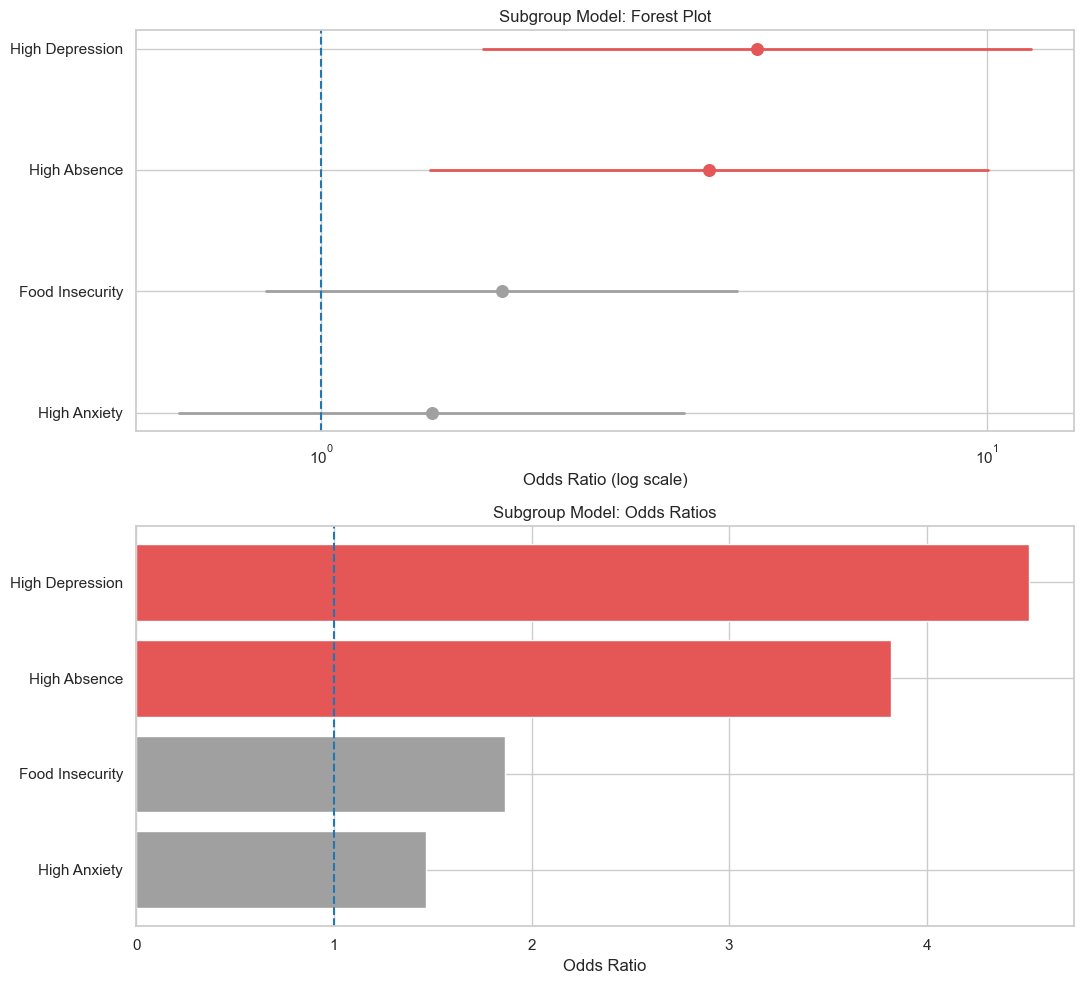

In [22]:
import statsmodels.api as sm
from IPython.display import display

# =========================================================
# Parsimonious Subgroup Logistic Regression
# Restricted to children with food allergy
# Outcome = poor_health (PHSTAT_C: 4/5 = 1)
# Main-result model with reduced predictors
# =========================================================

df = child_data.copy()


# Restrict to children with current food allergy
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df = df[curfood == 1].copy()

# Outcome: poor health (PHSTAT_C 4/5)
ph = pd.to_numeric(df["PHSTAT_C"], errors="coerce")
df["poor_health"] = np.where(
    ph.isin([4, 5]), 1,
    np.where(ph.isin([1, 2, 3]), 0, np.nan)
)

# Psychosocial predictors
anx = pd.to_numeric(df["ANXFREQ_C"], errors="coerce")
df["high_anxiety"] = np.where(
    anx.isin([1, 2]), 1,
    np.where(anx.isin([3, 4, 5]), 0, np.nan)
)

dep = pd.to_numeric(df["DEPFREQ_C"], errors="coerce")
df["high_depression"] = np.where(
    dep.isin([1, 2]), 1,
    np.where(dep.isin([3, 4, 5]), 0, np.nan)
)

sch = pd.to_numeric(df["SCHDYMSSTC_C"], errors="coerce")
df["high_absence"] = np.where(
    sch.between(18, 95), 1,
    np.where(sch.between(0, 17), 0, np.nan)
)

# Core SDOH predictors
# notcov = pd.to_numeric(df["NOTCOV_C"], errors="coerce")
# df["notcov_risk"] = np.where(notcov == 1, 1, np.where(notcov == 2, 0, np.nan))

fd = pd.to_numeric(df["FDSCAT4_C"], errors="coerce")
df["food_insecure"] = np.where(
    fd.isin([3, 4]), 1,
    np.where(fd.isin([1, 2]), 0, np.nan)
)

analysis_df_main = df[[
    "poor_health",
    "high_anxiety",
    "high_depression",
    "high_absence",
    "food_insecure"
]].dropna().copy()

for col in analysis_df_main.columns:
    analysis_df_main[col] = analysis_df_main[col].astype(int)

zero_variance_cols = [
    col for col in analysis_df_main.columns
    if col != "poor_health" and analysis_df_main[col].nunique() < 2
]
if zero_variance_cols:
    print("Dropped zero-variance predictors:", ", ".join(zero_variance_cols))
    analysis_df_main = analysis_df_main.drop(columns=zero_variance_cols)

print(f"Parsimonious model sample size: {len(analysis_df_main):,}")
print(f"Poor health = 1: {analysis_df_main['poor_health'].sum():,}")
print(f"Poor health = 0: {(analysis_df_main['poor_health'] == 0).sum():,}")

X = analysis_df_main.drop(columns=["poor_health"]).copy()
X = sm.add_constant(X, has_constant="add")
y = analysis_df_main["poor_health"]

logit_model = sm.Logit(y, X)
logit_result = logit_model.fit(disp=False, maxiter=300)

coef_df_main = pd.DataFrame({
    "variable": logit_result.params.index,
    "beta": logit_result.params.values,
    "odds_ratio": np.exp(logit_result.params.values),
    "p_value": logit_result.pvalues.values
})

conf = logit_result.conf_int()
coef_df_main["ci_lower"] = np.exp(conf[0].values)
coef_df_main["ci_upper"] = np.exp(conf[1].values)
coef_df_main = coef_df_main[coef_df_main["variable"] != "const"].copy()
coef_df_main["significant"] = coef_df_main["p_value"] < 0.05
coef_df_main["effect_size"] = np.abs(np.log(coef_df_main["odds_ratio"]))

name_map = {
    "high_anxiety": "High Anxiety",
    "high_depression": "High Depression",
    "high_absence": "High Absence",
    "food_insecure": "Food Insecurity"
}
coef_df_main["label"] = coef_df_main["variable"].map(name_map).fillna(coef_df_main["variable"])

results_main = coef_df_main.sort_values(["p_value", "effect_size"], ascending=[True, False]).reset_index(drop=True)
sig_results = results_main[results_main["significant"]].copy()

print("\nParsimonious subgroup logistic regression results:")
display(results_main[["label", "odds_ratio", "ci_lower", "ci_upper", "p_value", "significant"]])

print("\nInterpretation:")
for row in sig_results.itertuples(index=False):
    if row.odds_ratio >= 1:
        direction_text = f"{row.odds_ratio:.2f} times higher odds"
    else:
        direction_text = f"{1 / row.odds_ratio:.2f} times lower odds"
    print(
        f"- {row.label} is significantly associated with poor health "
        f"(OR={row.odds_ratio:.2f}, 95% CI {row.ci_lower:.2f}-{row.ci_upper:.2f}, p={row.p_value:.3g}). "
        f"This corresponds to {direction_text}."
    )

print("- This main-result model is restricted to children with current food allergy.")
print("- The outcome is poor health, defined as PHSTAT_C in 4 or 5.")
print("- The predictor set is reduced to improve stability and interpretability.")

# -----------------------------------
# Visualization
# -----------------------------------
plot_df = results_main.copy()
plot_df["color"] = np.where(plot_df["significant"], "#E45756", "#A0A0A0")
plot_df = plot_df.iloc[::-1]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(11, 10))

# 1) Forest plot
for i, row in enumerate(plot_df.itertuples(index=False)):
    axes[0].plot([row.ci_lower, row.ci_upper], [i, i], color=row.color, linewidth=2)
    axes[0].scatter(row.odds_ratio, i, color=row.color, s=70, zorder=3)

axes[0].axvline(1, color="#1F77B4", linestyle="--", linewidth=1.5)
axes[0].set_xscale("log")
axes[0].set_yticks(range(len(plot_df)))
axes[0].set_yticklabels(plot_df["label"])
axes[0].set_xlabel("Odds Ratio (log scale)")
axes[0].set_title("Subgroup Model: Forest Plot")

# 2) Bar chart
axes[1].barh(plot_df["label"], plot_df["odds_ratio"], color=plot_df["color"])
axes[1].axvline(1, color="#1F77B4", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Odds Ratio")
axes[1].set_title("Subgroup Model: Odds Ratios")

plt.tight_layout()
plt.show()


Sample size: 8,234
Poor health = 1: 191
Poor health = 0: 8,043

2x2 Table (counts):


Poor Health,0,1
Food Insecure,,
0,7130,135
1,913,56



2x2 Table (row %):


Poor Health,0,1
Food Insecure,,
0,98.14,1.86
1,94.22,5.78



Crude OR from 2x2 table: 3.2395

Simple logistic regression results:


,variable,odds_ratio,ci_lower,ci_upper,p_value
1,food_insecure,3.239463,2.354546,4.456961,5.181259e-13



Interpretation:
- Food insecurity is associated with poor health (OR=3.24, 95% CI 2.35-4.46, p=5.18e-13).
- This corresponds to 3.24 times higher odds of poor health.
- This is an unadjusted model restricted to children with current food allergy.


/var/folders/sc/_8qp44f14292wc07xsg6dkmr0000gn/T/ipykernel_58041/944510805.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


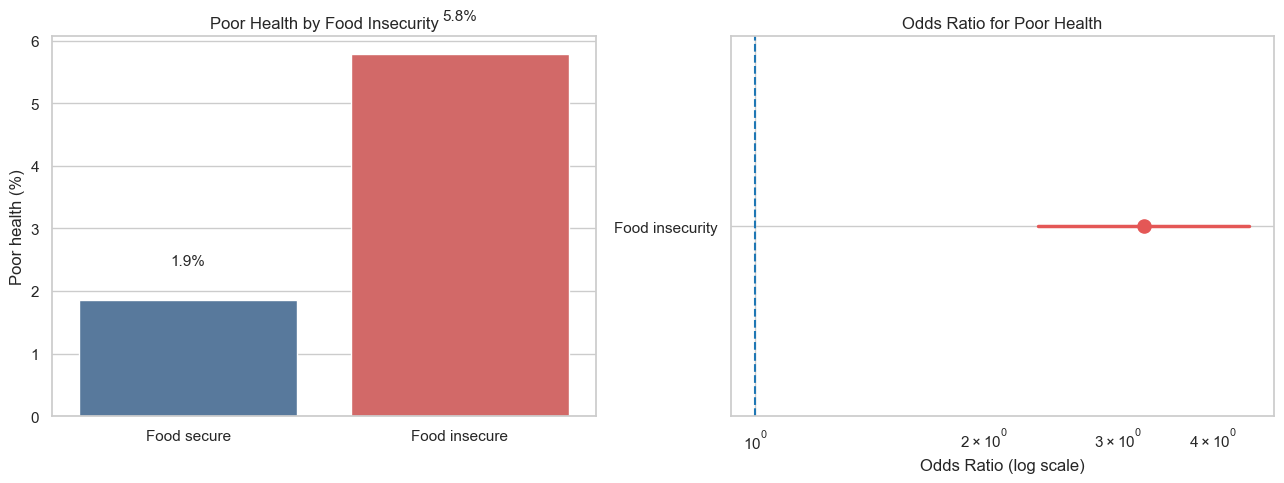

In [23]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# =========================================================
# Simple Logistic Regression + 2x2 Table + Graphs
# Restricted to children with current food allergy
# Outcome = poor_health
# Predictor = food_insecure only
# =========================================================

df = child_data.copy()

# Restrict to children with current food allergy
# curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
# df = df[curfood == 1].copy()

# Outcome: poor health (4/5 = 1, 1/2/3 = 0)
ph = pd.to_numeric(df["PHSTAT_C"], errors="coerce")
df["poor_health"] = np.where(
    ph.isin([4, 5]), 1,
    np.where(ph.isin([1, 2, 3]), 0, np.nan)
)

# Predictor: food insecurity
fd = pd.to_numeric(df["FDSCAT4_C"], errors="coerce")
df["food_insecure"] = np.where(
    fd.isin([3, 4]), 1,
    np.where(fd.isin([1, 2]), 0, np.nan)
)

# Analysis dataset
analysis_df = df[["poor_health", "food_insecure"]].dropna().copy()

for col in analysis_df.columns:
    analysis_df[col] = analysis_df[col].astype(int)

print(f"Sample size: {len(analysis_df):,}")
print(f"Poor health = 1: {analysis_df['poor_health'].sum():,}")
print(f"Poor health = 0: {(analysis_df['poor_health'] == 0).sum():,}")

# =========================================================
# 2x2 table
# =========================================================
table_2x2 = pd.crosstab(
    analysis_df["food_insecure"],
    analysis_df["poor_health"],
    rownames=["Food Insecure"],
    colnames=["Poor Health"],
    dropna=False
)

table_2x2 = table_2x2.reindex(index=[0, 1], columns=[0, 1], fill_value=0)

print("\n2x2 Table (counts):")
display(table_2x2)

row_pct = table_2x2.div(table_2x2.sum(axis=1), axis=0) * 100
print("\n2x2 Table (row %):")
display(row_pct.round(2))

a = table_2x2.loc[1, 1]
b = table_2x2.loc[1, 0]
c = table_2x2.loc[0, 1]
d = table_2x2.loc[0, 0]

if b > 0 and c > 0:
    crude_or = (a * d) / (b * c)
    print(f"\nCrude OR from 2x2 table: {crude_or:.4f}")
else:
    crude_or = np.nan
    print("\nCrude OR from 2x2 table: cannot compute because of zero cell count.")

# =========================================================
# Logistic regression
# =========================================================
X = analysis_df[["food_insecure"]].copy()
X = sm.add_constant(X, has_constant="add")
y = analysis_df["poor_health"]

logit_model = sm.Logit(y, X)
logit_result = logit_model.fit(disp=False, maxiter=300)

conf = logit_result.conf_int()
results = pd.DataFrame({
    "variable": logit_result.params.index,
    "beta": logit_result.params.values,
    "odds_ratio": np.exp(logit_result.params.values),
    "p_value": logit_result.pvalues.values,
    "ci_lower": np.exp(conf[0].values),
    "ci_upper": np.exp(conf[1].values)
})

results = results[results["variable"] != "const"].copy()

print("\nSimple logistic regression results:")
display(results[["variable", "odds_ratio", "ci_lower", "ci_upper", "p_value"]])

row = results.iloc[0]
if row["odds_ratio"] >= 1:
    direction_text = f"{row['odds_ratio']:.2f} times higher odds"
else:
    direction_text = f"{1 / row['odds_ratio']:.2f} times lower odds"

print("\nInterpretation:")
print(
    f"- Food insecurity is associated with poor health "
    f"(OR={row['odds_ratio']:.2f}, 95% CI {row['ci_lower']:.2f}-{row['ci_upper']:.2f}, p={row['p_value']:.3g})."
)
print(f"- This corresponds to {direction_text} of poor health.")
print("- This is an unadjusted model restricted to children with current food allergy.")

# =========================================================
# Visualization
# =========================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1) Bar plot: percent with poor health by food insecurity
plot_bar = (
    analysis_df.groupby("food_insecure")["poor_health"]
    .mean()
    .reset_index()
)
plot_bar["poor_health_pct"] = plot_bar["poor_health"] * 100
plot_bar["group"] = plot_bar["food_insecure"].map({
    0: "Food secure",
    1: "Food insecure"
})

sns.barplot(
    data=plot_bar,
    x="group",
    y="poor_health_pct",
    palette=["#4C78A8", "#E45756"],
    ax=axes[0]
)

axes[0].set_xlabel("")
axes[0].set_ylabel("Poor health (%)")
axes[0].set_title("Poor Health by Food Insecurity")

for i, val in enumerate(plot_bar["poor_health_pct"]):
    axes[0].text(i, val + 0.5, f"{val:.1f}%", ha="center", va="bottom", fontsize=11)

# 2) Forest plot: odds ratio with 95% CI
or_val = row["odds_ratio"]
ci_low = row["ci_lower"]
ci_high = row["ci_upper"]
sig_color = "#E45756" if row["p_value"] < 0.05 else "#A0A0A0"

axes[1].plot([ci_low, ci_high], [0, 0], color=sig_color, linewidth=2.5)
axes[1].scatter(or_val, 0, color=sig_color, s=90, zorder=3)
axes[1].axvline(1, color="#1F77B4", linestyle="--", linewidth=1.5)

axes[1].set_xscale("log")
axes[1].set_yticks([0])
axes[1].set_yticklabels(["Food insecurity"])
axes[1].set_xlabel("Odds Ratio (log scale)")
axes[1].set_title("Odds Ratio for Poor Health")
axes[1].set_ylim(-0.8, 0.8)

plt.tight_layout()
plt.show()


## Domain-Specific Logistic Regression Models

This section keeps the same setup used in the regression notebook: `poor_health` as the outcome and children with current food allergy only as the sample. It adds three domain-specific logistic regression models.



Psychosocial Model
Sample size: 518
Poor health = 1: 38
Poor health = 0: 480

Odds ratio, CI, and p-value table:


,label,odds_ratio,ci_lower,ci_upper,p_value,significant
0,High Depression,4.711898,1.844203,12.038794,0.001200,True
1,High School Absence,4.079461,1.586692,10.488487,0.003521,True
2,High Anxiety,1.497592,0.634759,3.533286,0.356448,False



Statistically significant variables:


,label,odds_ratio,ci_lower,ci_upper,p_value,significant
0,High Depression,4.711898,1.844203,12.038794,0.001200,True
1,High School Absence,4.079461,1.586692,10.488487,0.003521,True


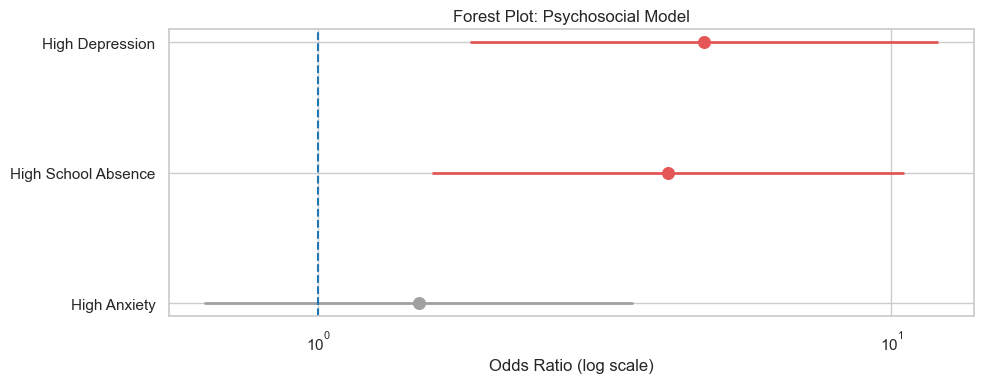


Social/Economic Model
Sample size: 465
Poor health = 1: 36
Poor health = 0: 429

Odds ratio, CI, and p-value table:


,label,odds_ratio,ci_lower,ci_upper,p_value,significant
0,Food Insecurity,2.070674,0.932692,4.597117,0.073659,False
1,School Meal Program,1.989330,0.858830,4.607932,0.108523,False
2,Low Parent Education,1.492657,0.670270,3.324069,0.326803,False
3,WIC,1.513416,0.397279,5.765289,0.543704,False
4,Uninsured,0.516584,0.059766,4.465075,0.548350,False
5,Insurance Coverage Risk,1.242139,0.498542,3.094842,0.641548,False
6,SNAP,1.077595,0.448010,2.591933,0.867459,False



Statistically significant variables: none at p < 0.05


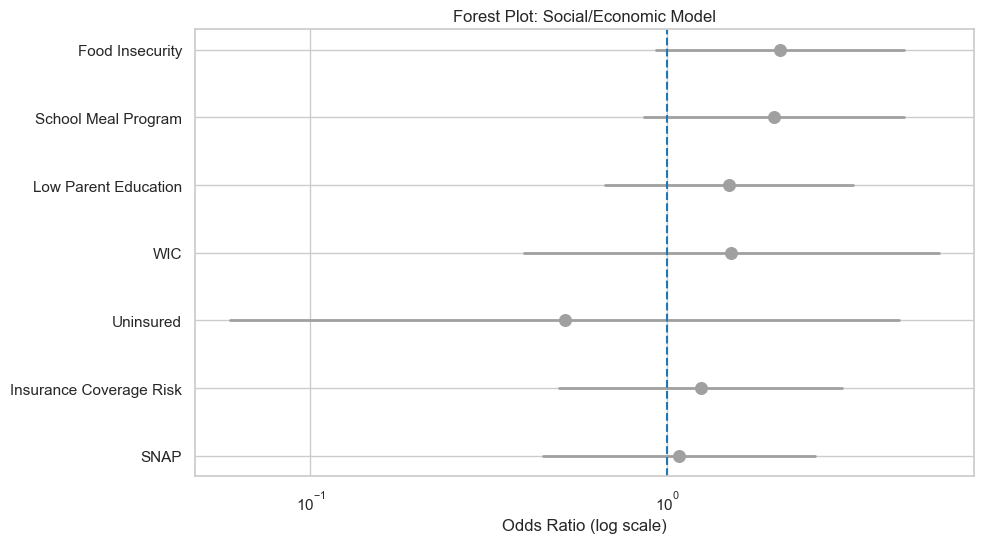


Environment Model
Sample size: 488
Poor health = 1: 37
Poor health = 0: 451

Odds ratio, CI, and p-value table:


,label,odds_ratio,ci_lower,ci_upper,p_value,significant
0,Housing: Rented,2.667224,1.321416,5.383680,0.006187,True
1,Traffic Risk,1.419155,0.666947,3.019732,0.363549,False
2,No Sidewalk,1.308408,0.500274,3.421988,0.583686,False
3,Crime Risk,0.795410,0.297181,2.128926,0.648614,False
4,No Parks,1.150982,0.516172,2.566509,0.731093,False



Statistically significant variables:


,label,odds_ratio,ci_lower,ci_upper,p_value,significant
0,Housing: Rented,2.667224,1.321416,5.38368,0.006187,True


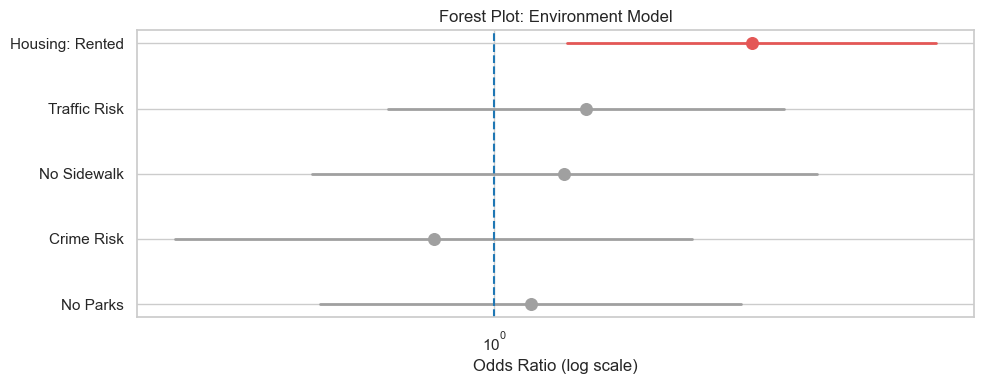


Comparison summary across the three models:


,Model,Sample N,Poor Health Cases,Significant Predictors,Top Signal,Fit Method
0,Psychosocial Model,518,38,2,"High Depression (OR=4.71, p=0.0012)",standard
1,Social/Economic Model,465,36,0,No statistically significant predictors,standard
2,Environment Model,488,37,1,"Housing: Rented (OR=2.67, p=0.00619)",standard



Brief comparison summary:
- Psychosocial Model: N=518, poor health cases=38, significant predictors=2, top signal=High Depression (OR=4.71, p=0.0012).
- Social/Economic Model: N=465, poor health cases=36, significant predictors=0, top signal=No statistically significant predictors.
- Environment Model: N=488, poor health cases=37, significant predictors=1, top signal=Housing: Rented (OR=2.67, p=0.00619).


In [24]:
import statsmodels.api as sm
from IPython.display import display

sns.set_theme(style="whitegrid")

def build_food_allergy_regression_data() -> pd.DataFrame:
    df = child_data.copy()

    age = pd.to_numeric(df["AGEP_C"], errors="coerce")
    df = df[age.between(5, 17)].copy()

    curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
    df = df[curfood == 1].copy()

    ph = pd.to_numeric(df["PHSTAT_C"], errors="coerce")
    df["poor_health"] = np.where(
        ph.isin([4, 5]), 1,
        np.where(ph.isin([1, 2, 3]), 0, np.nan)
    )

    anx = pd.to_numeric(df["ANXFREQ_C"], errors="coerce")
    df["high_anxiety"] = np.where(
        anx.isin([1, 2]), 1,
        np.where(anx.isin([3, 4, 5]), 0, np.nan)
    )

    dep = pd.to_numeric(df["DEPFREQ_C"], errors="coerce")
    df["high_depression"] = np.where(
        dep.isin([1, 2]), 1,
        np.where(dep.isin([3, 4, 5]), 0, np.nan)
    )

    sch = pd.to_numeric(df["SCHDYMSSTC_C"], errors="coerce")
    df["high_absence"] = np.where(
        sch.between(18, 95), 1,
        np.where(sch.between(0, 17), 0, np.nan)
    )

    notcov = pd.to_numeric(df["NOTCOV_C"], errors="coerce")
    df["notcov_risk"] = np.where(notcov == 1, 1, np.where(notcov == 2, 0, np.nan))

    cover = pd.to_numeric(df["COVER_C"], errors="coerce")
    df["cover_risk"] = np.where(cover == 1, 0, np.where(cover.isin([2, 4]), 1, np.nan))

    snap = pd.to_numeric(df["FSNAP12M_C"], errors="coerce")
    df["snap_risk"] = np.where(snap == 1, 1, np.where(snap == 2, 0, np.nan))

    wic = pd.to_numeric(df["FWIC12M_C"], errors="coerce")
    df["wic_risk"] = np.where(wic == 1, 1, np.where(wic == 2, 0, np.nan))

    meal = pd.to_numeric(df["FLUNCH12M1_C"], errors="coerce")
    df["meal_risk"] = np.where(meal == 1, 1, np.where(meal == 2, 0, np.nan))

    maxedu = pd.to_numeric(df["MAXPAREDUP_C"], errors="coerce")
    df["low_parent_education"] = np.where(
        maxedu.between(0, 5), 1,
        np.where(maxedu.between(6, 10), 0, np.nan)
    )

    fd = pd.to_numeric(df["FDSCAT4_C"], errors="coerce")
    df["food_insecure"] = np.where(
        fd.isin([3, 4]), 1,
        np.where(fd.isin([1, 2]), 0, np.nan)
    )

    house = pd.to_numeric(df["HOUTENURE_C"], errors="coerce")
    df["housing_rented"] = np.where(house == 2, 1, np.where(house == 1, 0, np.nan))

    sidewalk = pd.to_numeric(df["SIDEWALK_C"], errors="coerce")
    df["sidewalk_high_risk"] = np.where(sidewalk == 2, 1, np.where(sidewalk == 1, 0, np.nan))

    parks = pd.to_numeric(df["PARKS_C"], errors="coerce")
    df["parks_high_risk"] = np.where(parks == 2, 1, np.where(parks == 1, 0, np.nan))

    traffic = pd.to_numeric(df["TRAFFIC_C"], errors="coerce")
    df["traffic_high_risk"] = np.where(traffic == 1, 1, np.where(traffic == 2, 0, np.nan))

    crime = pd.to_numeric(df["CRIME_C"], errors="coerce")
    df["crime_high_risk"] = np.where(crime == 1, 1, np.where(crime == 2, 0, np.nan))

    return df

def separation_risk_columns(df: pd.DataFrame, outcome: str, predictors: list[str]) -> list[str]:
    flagged = []
    for col in predictors:
        ct = pd.crosstab(df[col], df[outcome])
        if ct.empty:
            flagged.append(col)
            continue
        if ((ct == 0).any(axis=1)).any():
            flagged.append(col)
    return flagged

def fit_domain_model(model_name: str, predictors: list[str], label_map: dict[str, str]):
    df = build_food_allergy_regression_data()
    analysis_df = df[["poor_health", *predictors]].dropna().copy()

    for col in analysis_df.columns:
        analysis_df[col] = analysis_df[col].astype(int)

    zero_variance = [col for col in predictors if analysis_df[col].nunique() < 2]
    if zero_variance:
        analysis_df = analysis_df.drop(columns=zero_variance)

    remaining = [col for col in predictors if col not in zero_variance]
    separation_risk = separation_risk_columns(analysis_df, "poor_health", remaining)
    if separation_risk:
        analysis_df = analysis_df.drop(columns=separation_risk)

    final_predictors = [col for col in predictors if col not in zero_variance and col not in separation_risk]

    print(f"\n{'=' * 80}")
    print(model_name)
    print(f"{'=' * 80}")
    print(f"Sample size: {len(analysis_df):,}")
    print(f"Poor health = 1: {analysis_df['poor_health'].sum():,}")
    print(f"Poor health = 0: {(analysis_df['poor_health'] == 0).sum():,}")
    if zero_variance:
        print("Dropped zero-variance predictors:", ", ".join(zero_variance))
    if separation_risk:
        print("Dropped separation-risk predictors:", ", ".join(separation_risk))

    if not final_predictors:
        print("No predictors remain after filtering. Model not fitted.")
        return {
            "model": model_name,
            "n": len(analysis_df),
            "events": int(analysis_df['poor_health'].sum()),
            "fit_method": "not_fitted",
            "results": pd.DataFrame()
        }

    X = sm.add_constant(analysis_df[final_predictors].copy(), has_constant="add")
    y = analysis_df["poor_health"]

    logit_model = sm.Logit(y, X)
    fit_method = "standard"
    try:
        logit_result = logit_model.fit(disp=False, method="lbfgs", maxiter=300)
        conf = logit_result.conf_int()
        pvalues = logit_result.pvalues
    except Exception as exc:
        print(f"Standard fit failed: {exc}")
        print("Falling back to regularized logistic regression.")
        fit_method = "regularized"
        logit_result = logit_model.fit_regularized(disp=False, alpha=1e-4, maxiter=300)
        try:
            conf = logit_result.conf_int()
        except Exception:
            conf = pd.DataFrame({0: [np.nan] * len(logit_result.params), 1: [np.nan] * len(logit_result.params)}, index=logit_result.params.index)
        try:
            pvalues = logit_result.pvalues
        except Exception:
            pvalues = pd.Series(np.nan, index=logit_result.params.index)

    results = pd.DataFrame({
        "variable": logit_result.params.index,
        "odds_ratio": np.exp(logit_result.params.values),
        "p_value": pvalues.values,
        "ci_lower": np.exp(conf[0].values),
        "ci_upper": np.exp(conf[1].values)
    })
    results = results[results["variable"] != "const"].copy()
    results["label"] = results["variable"].map(label_map).fillna(results["variable"])
    results["significant"] = results["p_value"] < 0.05
    results = results[["label", "odds_ratio", "ci_lower", "ci_upper", "p_value", "significant"]]
    results = results.sort_values(["significant", "p_value", "odds_ratio"], ascending=[False, True, False]).reset_index(drop=True)

    print("\nOdds ratio, CI, and p-value table:")
    display(results)

    sig_results = results[results["significant"]].copy()
    if sig_results.empty:
        print("\nStatistically significant variables: none at p < 0.05")
    else:
        print("\nStatistically significant variables:")
        display(sig_results)

    plot_df = results.iloc[::-1].copy()
    plot_df["color"] = np.where(plot_df["significant"], "#E45756", "#A0A0A0")

    plt.figure(figsize=(10, max(4, 0.8 * len(plot_df))))
    for i, row in enumerate(plot_df.itertuples(index=False)):
        if np.isfinite(row.ci_lower) and np.isfinite(row.ci_upper):
            plt.plot([row.ci_lower, row.ci_upper], [i, i], color=row.color, linewidth=2)
        plt.scatter(row.odds_ratio, i, color=row.color, s=70, zorder=3)
    plt.axvline(1, color="#1F77B4", linestyle="--", linewidth=1.5)
    plt.xscale("log")
    plt.yticks(range(len(plot_df)), plot_df["label"])
    plt.xlabel("Odds Ratio (log scale)")
    plt.title(f"Forest Plot: {model_name}")
    plt.tight_layout()
    plt.show()

    return {
        "model": model_name,
        "n": len(analysis_df),
        "events": int(analysis_df['poor_health'].sum()),
        "fit_method": fit_method,
        "results": results
    }

psychosocial_predictors = ["high_anxiety", "high_depression", "high_absence"]
psychosocial_labels = {
    "high_anxiety": "High Anxiety",
    "high_depression": "High Depression",
    "high_absence": "High School Absence"
}

social_predictors = [
    "notcov_risk",
    "cover_risk",
    "snap_risk",
    "wic_risk",
    "meal_risk",
    "low_parent_education",
    "food_insecure"
]
social_labels = {
    "notcov_risk": "Uninsured",
    "cover_risk": "Insurance Coverage Risk",
    "snap_risk": "SNAP",
    "wic_risk": "WIC",
    "meal_risk": "School Meal Program",
    "low_parent_education": "Low Parent Education",
    "food_insecure": "Food Insecurity"
}

environment_predictors = [
    "housing_rented",
    "sidewalk_high_risk",
    "parks_high_risk",
    "traffic_high_risk",
    "crime_high_risk"
]
environment_labels = {
    "housing_rented": "Housing: Rented",
    "sidewalk_high_risk": "No Sidewalk",
    "parks_high_risk": "No Parks",
    "traffic_high_risk": "Traffic Risk",
    "crime_high_risk": "Crime Risk"
}

model_outputs = [
    fit_domain_model("Psychosocial Model", psychosocial_predictors, psychosocial_labels),
    fit_domain_model("Social/Economic Model", social_predictors, social_labels),
    fit_domain_model("Environment Model", environment_predictors, environment_labels)
]

comparison_rows = []
for output in model_outputs:
    results = output["results"]
    sig_results = results[results["significant"]].copy() if not results.empty else pd.DataFrame()
    if sig_results.empty:
        top_signal = "No statistically significant predictors"
    else:
        top_row = sig_results.sort_values("p_value").iloc[0]
        top_signal = f"{top_row['label']} (OR={top_row['odds_ratio']:.2f}, p={top_row['p_value']:.3g})"
    comparison_rows.append({
        "Model": output["model"],
        "Sample N": output["n"],
        "Poor Health Cases": output["events"],
        "Significant Predictors": int(sig_results.shape[0]),
        "Top Signal": top_signal,
        "Fit Method": output["fit_method"]
    })

comparison_df = pd.DataFrame(comparison_rows)
print("\nComparison summary across the three models:")
display(comparison_df)

print("\nBrief comparison summary:")
for row in comparison_df.itertuples(index=False):
    print(
        f"- {row[0]}: N={row[1]:,}, poor health cases={row[2]:,}, significant predictors={row[3]}, top signal={row[4]}."
    )


## Selected Six-Predictor Model

This cell fits one additional logistic regression model using the six predictors with the largest odds ratios of interest: high depression, high school absence, school meal, no sidewalk, food insecurity, and low parent education.



Selected Six-Predictor Model
Sample size: 477
Poor health = 1: 36
Poor health = 0: 441

Odds ratio, CI, and p-value table:


,label,odds_ratio,ci_lower,ci_upper,p_value,significant
0,High Depression,5.024605,2.173698,11.614611,0.000159,True
1,High School Absence,3.684917,1.400790,9.693538,0.008219,True
2,School Meal Program,2.412751,1.049258,5.548078,0.038159,True
3,Low Parent Education,1.553723,0.718653,3.359138,0.262652,False
4,Food Insecurity,1.424209,0.604858,3.353466,0.418336,False
5,No Sidewalk,1.332679,0.524481,3.386264,0.546106,False



Statistically significant variables:


,label,odds_ratio,ci_lower,ci_upper,p_value,significant
0,High Depression,5.024605,2.173698,11.614611,0.000159,True
1,High School Absence,3.684917,1.400790,9.693538,0.008219,True
2,School Meal Program,2.412751,1.049258,5.548078,0.038159,True


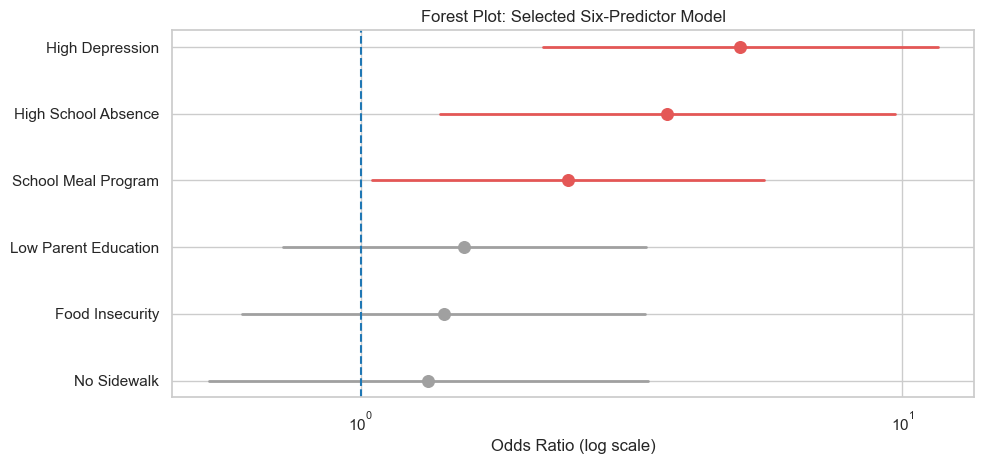


Selected model summary:
- Sample N: 477
- Poor health cases: 36
- Fit method: standard
- Significant predictors: 3


In [25]:
selected_predictors = [
    "high_depression",
    "high_absence",
    "meal_risk",
    "sidewalk_high_risk",
    "food_insecure",
    "low_parent_education"
]

selected_labels = {
    "high_depression": "High Depression",
    "high_absence": "High School Absence",
    "meal_risk": "School Meal Program",
    "sidewalk_high_risk": "No Sidewalk",
    "food_insecure": "Food Insecurity",
    "low_parent_education": "Low Parent Education"
}

selected_model_output = fit_domain_model(
    "Selected Six-Predictor Model",
    selected_predictors,
    selected_labels
)

selected_results = selected_model_output["results"]
selected_sig = selected_results[selected_results["significant"]].copy() if not selected_results.empty else pd.DataFrame()

print("\nSelected model summary:")
print(f"- Sample N: {selected_model_output['n']:,}")
print(f"- Poor health cases: {selected_model_output['events']:,}")
print(f"- Fit method: {selected_model_output['fit_method']}")
print(f"- Significant predictors: {selected_sig.shape[0]}")
